<a href="https://colab.research.google.com/github/chaehyeonkim-lab/bioinformatics1/blob/main/Binformatics_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIN28A가 결합하지만 번역 억제를 받지 않는 ER-associated mRNA 후보 탐색

논문에서의 흐름은 다음과 같다.

LIN28A가 mRNA에 결합한다. 특히 ER/membrane/secretory 관련 mRNA에 많이 결합하는데, 이들은 LIN28A을 knockdown한 경우 ribosome의 density가 증가하는 경향성을 보였다. 따라서 LIN28A는 ER-associated translation을 억제한다.

하지만 여기에는 분명히 예외가 존재한다.

LIN28A가 결합하는 ER-associated mRNA임에도 불구하고, Lin28a knockdown 후 ribosome density가 증가하지 않는 mRNA는 실제로 논문의 Figure 5.B에서도 확인 가능하다.


다음과 같이 그룹을 분류 가능하다.

LIN28A-bound ER mRNA
- CLIP enrichment가 높음
- localization annotation상 ER/membrane/secretory 관련

  1. Suppressed ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density 증가
   - 원래 LIN28A가 번역을 억제했을 가능성이 높음

  2. Escapee ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density가 증가하지 않음
   - LIN28A가 붙었지만 번역 억제 효과가 뚜렷하지 않음

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

fatal: destination path 'colab-biolab' already exists and is not an empty directory.
./
./root/
./root/.condarc
./root/.profile
./root/.bashrc.biolab
./root/.tmux.conf
./root/.bin.priority/
./root/.bin.priority/pip2
./root/.bin.priority/pip
./root/.bin.priority/pip3
./root/.vimrc
PREFIX=/root/conda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /root/conda
Activated conda environment `lab'!


In [13]:
!ls -al /content/drive/MyDrive/binfo1-datapack1/

total 7162852
-r-------- 1 root root 1370036258 Apr 27  2023 CLIP-35L33G.bam
-r-------- 1 root root    3118336 Apr 27  2023 CLIP-35L33G.bam.bai
-r-------- 1 root root       7113 May 11  2023 CLIP-let7g.bam
-r-------- 1 root root      14561 May 11  2023 CLIP-let7g-gene.pileup
-r-------- 1 root root    2685065 May 11  2023 CLIP-let7g.pileup
-r-------- 1 root root  883334756 Apr 27  2023 gencode.gtf
-r-------- 1 root root   24065406 Apr 27  2023 read-counts.txt
-r-------- 1 root root        751 Apr 27  2023 read-counts.txt.summary
-r-------- 1 root root 1003658801 Apr 27  2023 RNA-control.bam
-r-------- 1 root root    2276104 Apr 27  2023 RNA-control.bam.bai
-r-------- 1 root root 1260991122 Apr 27  2023 RNA-siLin28a.bam
-r-------- 1 root root    2710744 Apr 27  2023 RNA-siLin28a.bam.bai
-r-------- 1 root root  981684502 Apr 27  2023 RNA-siLuc.bam
-r-------- 1 root root    2606104 Apr 27  2023 RNA-siLuc.bam.bai
-r-------- 1 root root  737352902 Apr 27  2023 RPF-siLin28a.bam
-r-------- 1 r

In [14]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -y subread

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: / - \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - subread


The following packages will be UPDATED:

  ca-certificates    pkgs/main/linux-64::ca-certificates-2~ --> conda-forge/noarch::ca-certificates-2026.5.20-hbd8a1cb_0 
  certifi            pkgs/main/linux-64::certifi-2026.4.22~ --> conda-forge/noarch::certifi-2026.5.20-pyhd8ed1ab_0 
  conda              pkgs/main::conda-26.3.2-py313h06a4308~ --> conda-forge::conda-26.3.2-py313h78bf25f_1 
  openssl               pkgs/main

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [16]:
cnts = pd.read_csv('/content/drive/MyDrive/binfo1-datapack1/read-counts.txt', sep='\t', comment='#', index_col=0)

pseudo = 1
df = cnts.copy()

# read count가 너무 낮으면 비율 계산이 불안정하므로 제외
df = df[
    (df['RNA-control.bam'] > 10) &
    (df['RNA-siLuc.bam'] > 10) &
    (df['RNA-siLin28a.bam'] > 10)
].copy()

# LIN28A 결합 강도
df['clip_log2'] = np.log2(
    (df['CLIP-35L33G.bam'] + pseudo) /
    (df['RNA-control.bam'] + pseudo)
)

# control 조건의 ribosome density
df['rden_siLuc'] = (
    (df['RPF-siLuc.bam'] + pseudo) /
    (df['RNA-siLuc.bam'] + pseudo)
)

# Lin28a knockdown 조건의 ribosome density
df['rden_siLin28a'] = (
    (df['RPF-siLin28a.bam'] + pseudo) /
    (df['RNA-siLin28a.bam'] + pseudo)
)

# Lin28a knockdown 후 ribosome density 변화
df['rden_log2'] = np.log2(
    df['rden_siLin28a'] / df['rden_siLuc']
)

# RNA abundance 변화
df['rna_change_log2'] = np.log2(
    (df['RNA-siLin28a.bam'] + pseudo) /
    (df['RNA-siLuc.bam'] + pseudo)
)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['clip_log2', 'rden_log2', 'rna_change_log2'])

In [18]:
!curl -k -L -o mouselocalization-20210507.txt https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt

import pandas as pd

local = pd.read_csv('mouselocalization-20210507.txt', sep='\t')
local.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  402k  100  402k    0     0   265k      0  0:00:01  0:00:01 --:--:--  265k


,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


In [22]:
# df: read-counts.txt에서 계산한 표
# local: mouselocalization-20210507.txt에서 읽은 표

merged = df.copy().reset_index()

# reset_index() 후 첫 번째 column이 gene id입니다.
# 이름을 gene_id_count로 바꿔줍니다.
merged = merged.rename(columns={merged.columns[0]: 'gene_id_count'})

# gene id 뒤에 버전 번호가 붙어 있을 수 있으므로 제거합니다.
# 예: ENSMUSG00000000001.4 -> ENSMUSG00000000001
merged['gene_id_base'] = (
    merged['gene_id_count']
    .astype(str)
    .str.replace(r'\.\d+$', '', regex=True)
)

local2 = local.copy()

local2['gene_id_base'] = (
    local2['gene_id']
    .astype(str)
    .str.replace(r'\.\d+$', '', regex=True)
)

# 같은 gene_id가 여러 번 있을 수 있으므로 하나로 합칩니다.
local2 = (
    local2
    .groupby('gene_id_base', as_index=False)
    .agg({
        'Gene names': lambda x: '; '.join(sorted(set(x.astype(str)))),
        'type': lambda x: '; '.join(sorted(set(x.astype(str))))
    })
)

# read count 정보와 localization 정보를 합칩니다.
merged = merged.merge(local2, on='gene_id_base', how='left')

print("전체 gene 수:", len(merged))
print("localization annotation이 붙은 gene 수:", merged['type'].notna().sum())
print("localization annotation이 없는 gene 수:", merged['type'].isna().sum())

merged[['gene_id_count', 'Gene names', 'type', 'clip_log2', 'rden_log2', 'rna_change_log2']].head()

전체 gene 수: 12937
localization annotation이 붙은 gene 수: 6223
localization annotation이 없는 gene 수: 6714


,gene_id_count,Gene names,type,clip_log2,rden_log2,rna_change_log2
0,ENSMUSG00000102343.2,NaN,NaN,1.087463,-0.981621,0.396659
1,ENSMUSG00000102269.2,NaN,NaN,-3.039528,-3.009984,1.273018
2,ENSMUSG00000098104.2,NaN,NaN,-1.093109,-2.169925,0.754888
3,ENSMUSG00000103922.2,NaN,NaN,0.938599,-0.718040,-0.103623
4,ENSMUSG00000033845.14,NaN,NaN,1.566043,-1.016743,0.237585


In [23]:
# 현재 localization 파일에서는 integral membrane이 ER-associated translation과 가장 가까운 proxy입니다.
# 그래도 혹시 다른 단어가 있을 경우를 대비해서 pattern을 넓게 잡습니다.

er_pattern = r'integral membrane|membrane|secret|endoplasmic|reticulum|golgi|lumen|extracellular|cell surface|plasma membrane'

merged['er_related'] = (
    merged['type']
    .astype(str)
    .str.contains(er_pattern, case=False, regex=True, na=False)
)

print(merged['er_related'].value_counts())

merged.loc[
    merged['er_related'],
    ['gene_id_count', 'Gene names', 'type']
].head(20)

er_related
False    11387
True      1550
Name: count, dtype: int64


,gene_id_count,Gene names,type
47,ENSMUSG00000032769.6,Trpa1 Anktm1,integral membrane
50,ENSMUSG00000025921.8,Rdh10,integral membrane
56,ENSMUSG00000042686.6,Jph1 Jp1,integral membrane
61,ENSMUSG00000025931.16,Paqr8 Mprb,integral membrane
64,ENSMUSG00000025933.16,Tmem14a,integral membrane
69,ENSMUSG00000026156.9,B3gat2 Glcats,integral membrane
80,ENSMUSG00000073725.9,Lmbrd1,integral membrane
90,ENSMUSG00000026131.21,Dst Bpag1 Macf2,integral membrane
97,ENSMUSG00000037503.13,Fam168b Kiaa4042,integral membrane
98,ENSMUSG00000026123.12,Plekhb2 Evt2,integral membrane


In [24]:
# LIN28A 결합 강도 상위 10%를 strong binder로 정의합니다.
clip_cutoff = merged['clip_log2'].quantile(0.90)

print("LIN28A strong binding cutoff:", clip_cutoff)

# 조건 정의
strong_binding = merged['clip_log2'] >= clip_cutoff
er_related = merged['er_related']

# mRNA abundance가 크게 감소하지 않는 조건
# log2 fold change가 -0.5 이상이면 약 0.71배 이상 유지된다는 뜻입니다.
rna_not_decreased = merged['rna_change_log2'] >= -0.5

# Lin28a knockdown 후 ribosome density가 증가한 경우
translation_derepressed = merged['rden_log2'] > 0.5

# Lin28a knockdown 후 ribosome density가 증가하지 않은 경우
translation_escapee = merged['rden_log2'] <= 0

merged['group'] = 'Other'

merged.loc[
    strong_binding & er_related & rna_not_decreased,
    'group'
] = 'LIN28A-bound ER-related mRNA'

merged.loc[
    strong_binding & er_related & rna_not_decreased & translation_derepressed,
    'group'
] = 'Suppressed-like ER target'

merged.loc[
    strong_binding & er_related & rna_not_decreased & translation_escapee,
    'group'
] = 'Escapee ER target'

merged['group'].value_counts()

LIN28A strong binding cutoff: 2.3619019071982827


,count
group,
Other,12573
Escapee ER target,176
LIN28A-bound ER-related mRNA,164
Suppressed-like ER target,24


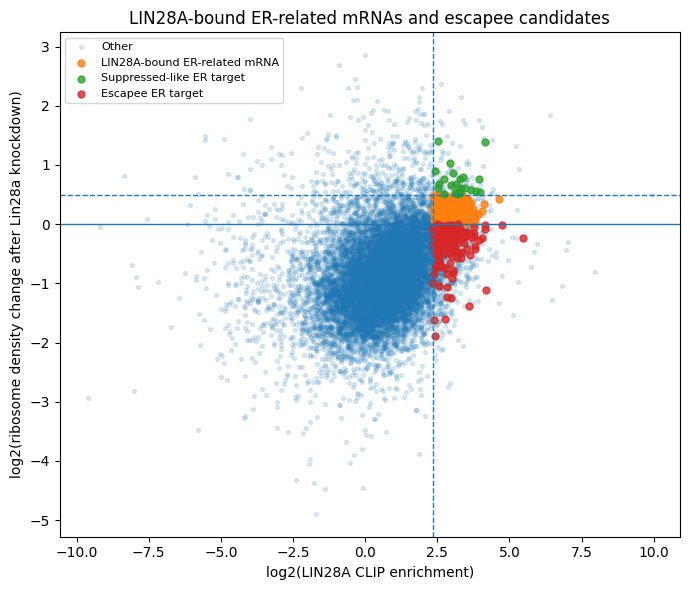

In [25]:
plt.figure(figsize=(7, 6))

# Other는 배경처럼 연하게 찍기
other = merged[merged['group'] == 'Other']

plt.scatter(
    other['clip_log2'],
    other['rden_log2'],
    s=8,
    alpha=0.15,
    label='Other'
)

# 주요 그룹만 따로 강조
for group_name in [
    'LIN28A-bound ER-related mRNA',
    'Suppressed-like ER target',
    'Escapee ER target'
]:
    sub = merged[merged['group'] == group_name]

    plt.scatter(
        sub['clip_log2'],
        sub['rden_log2'],
        s=25,
        alpha=0.8,
        label=group_name
    )

plt.axvline(clip_cutoff, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xlabel('log2(LIN28A CLIP enrichment)')
plt.ylabel('log2(ribosome density change after Lin28a knockdown)')
plt.title('LIN28A-bound ER-related mRNAs and escapee candidates')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [26]:
escapees = merged[merged['group'] == 'Escapee ER target'].copy()

# 해석하기 쉽게 정렬합니다.
# 1순위: LIN28A 결합이 강한 것
# 2순위: rden_log2가 낮은 것
# 3순위: RNA 변화가 0에 가까운 것
escapees['abs_rna_change'] = escapees['rna_change_log2'].abs()

escapees = escapees.sort_values(
    ['clip_log2', 'rden_log2', 'abs_rna_change'],
    ascending=[False, True, True]
)

cols = [
    'gene_id_count',
    'Gene names',
    'type',
    'Length',
    'clip_log2',
    'rden_log2',
    'rna_change_log2',
    'rden_siLuc',
    'rden_siLin28a'
]

escapees[cols].head(30)

,gene_id_count,Gene names,type,Length,clip_log2,rden_log2,rna_change_log2,rden_siLuc,rden_siLin28a
12534,ENSMUSG00000006373.11,Pgrmc1 Pgrmc,integral membrane,1857,5.457672,-0.231807,0.161589,1.336508,1.138127
2590,ENSMUSG00000070972.14,Dnajc25,integral membrane,4542,4.761551,-0.015332,0.140863,0.564103,0.558140
9318,ENSMUSG00000038732.16,Mboat1 Lpeat1 Oact1,integral membrane,3659,4.203872,-1.105377,1.152003,50.740741,23.583333
3469,ENSMUSG00000039156.20,Stim2 Kiaa1482,integral membrane,5133,4.167665,-0.090118,0.239383,1.029268,0.966942
7908,ENSMUSG00000020368.16,Canx,integral membrane,4693,4.155928,-0.021236,0.145697,3.138088,3.092235
309,ENSMUSG00000032883.16,Acsl3 Acs3 Facl3,integral membrane,4357,4.045219,-0.233582,-0.115545,0.863611,0.734519
12744,ENSMUSG00000033792.13,Atp7a Mnk,integral membrane,8734,3.930528,-0.271013,0.279073,2.176829,1.804020
410,ENSMUSG00000009905.6,Kdsr Fvt1,integral membrane,8147,3.820228,-0.369402,0.460004,1.179039,0.912698
105,ENSMUSG00000037408.11,Cnnm4 Acdp4 Kiaa1592,integral membrane,4829,3.809897,-0.419332,0.511778,0.877419,0.656109
12805,ENSMUSG00000031438.12,Rnf128 Grail Greul1 MNCb-3816,integral membrane,3464,3.787903,-0.046309,0.658384,1.481928,1.435115


group
Escapee ER target            176
Suppressed-like ER target     24
Name: count, dtype: int64


/tmp/ipykernel_4478/2735257339.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


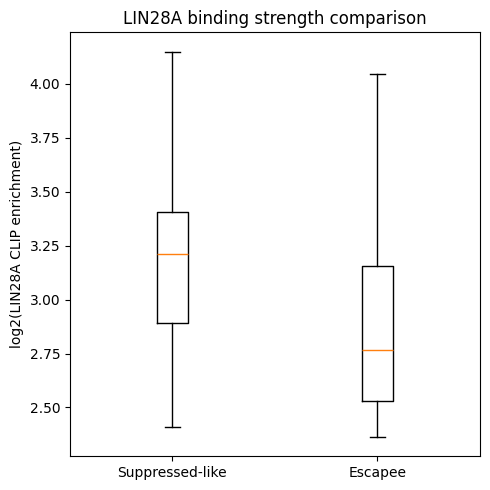

In [27]:
target_df = merged[
    merged['group'].isin(['Suppressed-like ER target', 'Escapee ER target'])
].copy()

print(target_df['group'].value_counts())

plt.figure(figsize=(5, 5))

plot_data = [
    target_df.loc[target_df['group'] == 'Suppressed-like ER target', 'clip_log2'],
    target_df.loc[target_df['group'] == 'Escapee ER target', 'clip_log2']
]

plt.boxplot(
    plot_data,
    labels=['Suppressed-like', 'Escapee'],
    showfliers=False
)

plt.ylabel('log2(LIN28A CLIP enrichment)')
plt.title('LIN28A binding strength comparison')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4478/3284811208.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


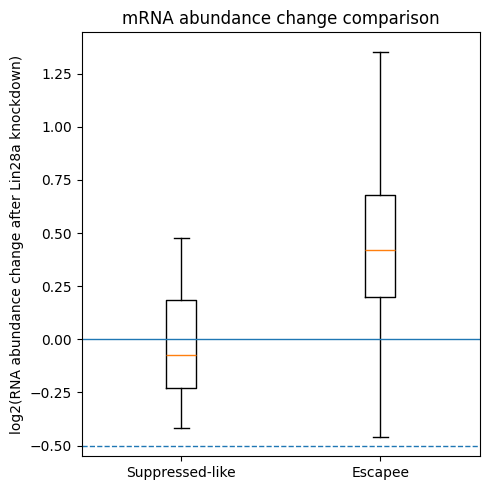

In [28]:
plt.figure(figsize=(5, 5))

plot_data = [
    target_df.loc[target_df['group'] == 'Suppressed-like ER target', 'rna_change_log2'],
    target_df.loc[target_df['group'] == 'Escapee ER target', 'rna_change_log2']
]

plt.boxplot(
    plot_data,
    labels=['Suppressed-like', 'Escapee'],
    showfliers=False
)

plt.axhline(0, linewidth=1)
plt.axhline(-0.5, linestyle='--', linewidth=1)

plt.ylabel('log2(RNA abundance change after Lin28a knockdown)')
plt.title('mRNA abundance change comparison')

plt.tight_layout()
plt.show()

In [29]:
escapees[cols].to_csv('LIN28A_ER_escapee_candidates.csv', index=False)

target_df[cols + ['group']].to_csv('LIN28A_ER_target_groups.csv', index=False)

print("저장 완료:")
print("1. LIN28A_ER_escapee_candidates.csv")
print("2. LIN28A_ER_target_groups.csv")

저장 완료:
1. LIN28A_ER_escapee_candidates.csv
2. LIN28A_ER_target_groups.csv


In [30]:
from google.colab import files

files.download('LIN28A_ER_escapee_candidates.csv')
files.download('LIN28A_ER_target_groups.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>